# Generación de Imágenes - Ejercicio complementario

En este Notebook vamos a afianzar algunos de los conceptos que hemos trabajado en clase, realizando diversos ejercicios con LLMs y Modelos de Generación de Imagen

1) Subir una imagen a un Bucket en Google Cloud Storage
2) Obtener una descripción detallada de la imagen
3) Generar mediante IA una réplica de la imagen a partir de su descripción

### Instalar el SDK de Python de Vertex AI

Instala las dependencias necesarias para realizar llamadas programáticas a los modelos de Google

In [13]:
%pip install --upgrade --quiet google-genai

### Autentica tu entorno de cuaderno (solo Colab)

Si estás ejecutando este cuaderno en Google Colab, ejecuta la siguiente celda para autenticar tu entorno.

In [14]:
import sys

if "google.colab" in sys.modules:
    from google.colab import auth

    auth.authenticate_user()

### Importa las librerias necesarias

In [15]:
from google import genai
from google.genai import types

import urllib
from PIL import Image as PIL_Image
import matplotlib.pyplot as plt

### Inicializar Vertex AI en nuestro Google Cloud Project

In [16]:
# Importar Vertex AI
import vertexai

# Definir la info del proyecto
PROJECT_ID = ""  # @param {type:"string"}
# Vamos a utilizar esta localización por defecto
LOCATION = "us-central1"

# Inicializar el módulo
client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)

Vamos a verificar que todo está en orden y qué modo estamos utilizando



In [21]:
if not client.vertexai:
    print("Usando Gemini Developer API.")
elif client._api_client.project:
    print(
        f"Usando Vertex AI en la localización: {client._api_client.location}"
    )
elif client._api_client.api_key:
    print(
        f"Usando Vertex AI en modo express con API key: {client._api_client.api_key[:5]}...{client._api_client.api_key[-5:]}"
    )

Usando Vertex AI en la localización: us-central1


### Ejercicio 1 (opcional) - Subir una imagen a un Bucket de Google Cloud Storage

Este ejercicio describe los pasos necesarios para cargar un archivo de imagen en Google Cloud Storage utilizando la consola web de Google Cloud (UI).

---

#### Paso 1: Acceder a Cloud Storage
1. Inicia sesión en la [Consola de Google Cloud](https://console.cloud.google.com/).
2. En el buscador de la barra superior, escribe **"Cloud Storage"**.
3. Selecciona la opción **Buckets** en los resultados de búsqueda.

#### Paso 2: Seleccionar o crear un Bucket
Para alojar la imagen, debes estar dentro de un bucket:
* **Si ya tienes un bucket:** Haz clic sobre su nombre en la lista.
* **Si necesitas crear uno nuevo:**
    1. Haz clic en el botón **+ CREAR**.
    2. **Nombre:** Asígnale un nombre único a nivel mundial.
    3. **Ubicación:** Elige una región cercana a tus usuarios (ej. `us-central1`).
    4. Haz clic en **CREAR** (puedes dejar el resto de opciones por defecto).

#### Paso 3: Subir el fichero
Una vez que estés visualizando el contenido del bucket (pestaña **Objetos**):
1. Haz clic en el botón **SUBIR ARCHIVOS** (ubicado en la barra de herramientas superior).
2. Se abrirá el explorador de archivos de tu sistema operativo.
3. Busca y selecciona la **imagen** que deseas subir. Para este ejercicio puedes usar la imagen `Como.png` que encontrarás en tus materiales de clase.
4. Haz clic en **Abrir**.

#### Paso 4: Confirmación
1. Observa el cuadro de progreso en la parte inferior derecha de la pantalla.
2. Al finalizar, la imagen aparecerá listada en la tabla de **Objetos**.
3. (Opcional) Haz clic sobre el nombre del archivo para ver sus detalles, como la **URL autenticada** o el **Hash MD5**.

---

> **Nota:** Por seguridad, los objetos subidos son **privados por defecto**. Solo los usuarios con permisos de IAM adecuados podrán visualizar la imagen a menos que se configure el acceso público.

#### Paso 5: Copiar la GS URI de nuestra imagen subida
Al hacer click en los detalles de la imágen, tenemos que copiar el valor del parámetro **URI de gsutil** en el siguiente bloque de código
- Tendrá el formato: `gs://bucket_name/path_to_file.png`


In [18]:
# Copiar el GS URI de la imagen
gs_uri = "gs://alvarolamas-public/Como.png"  # @param {type:"string"}

# 1. Quitamos el prefijo 'gs://'
clean_uri = gs_uri.replace("gs://", "")

# 2. Dividimos solo en la primera ocurrencia de '/'
# split(separador, máximo de divisiones)
parts = clean_uri.split("/", 1)

bucket_name = parts[0]
path = parts[1]

print(f"bucket name: {bucket_name}")
print(f"path: {path}")


bucket name: alvarolamas-public
path: Como.png


### Ejercicio 2 - Obtener una descripción detallada de la imagen

A partir de la imagen que hemos subido al Bucket de Google Cloud Storage, vamos a obtener una descripción detallada utilizando el modelo `gemini-2.5-flash` (o el correspondiente modelo reciente, que podemos comprobar [en esta lista](https://docs.cloud.google.com/vertex-ai/generative-ai/docs/learn/model-versions?hl=es-419))

IMPORTANTE: Si no hemos subido ninguna imagen podemos realizar esta práctica con alguna de estas imagenes de prueba:
- `gs://cloud-samples-data/generative-ai/image/suitcase.png`
- `gs://alvarolamas-public/Como.png`

Para ello tendremos simplemente que ejecutar la celda anterior

In [19]:
# 1. Definir el prompt para describir la imagen
prompt = """Genera una descripción detallada de la imagen proporcionada."""

# 2. Definir la referencia a la imagen en GCS
image_part = types.Part.from_uri(
    file_uri=gs_uri,
    mime_type="image/png"
)

# 3. Generar la descripción detallada
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[prompt, image_part]
)

image_description = response.text
print(image_description)

Esta es una vista aérea vibrante y detallada de un pintoresco pueblo costero situado en una exuberante península, enclavado en las orillas de un vasto cuerpo de agua dulce o salada, con majestuosas montañas al fondo.

**Descripción general:**
La imagen presenta un paisaje idílico bajo un cielo azul brillante salpicado de nubes blancas y algodonosas. La luz del sol es intensa y clara, resaltando los colores vivos de la escena y creando sombras nítidas. La composición es equilibrada, con la península central como punto focal principal, rodeada de agua de un profundo color turquesa y flanqueada por una imponente cordillera.

**Elementos específicos:**

1.  **El Agua (Lago/Mar):**
    *   El cuerpo de agua ocupa una gran parte del encuadre, mostrando tonalidades que varían desde el azul profundo en la distancia hasta un vibrante turquesa y verde esmeralda cerca de la costa, indicando su claridad.
    *   La superficie del agua es mayormente tranquila, con pequeñas ondulaciones y algunas es

### Ejercicio 3 - Generación de una réplica
Una vez obtenida la descripción de la imagen, vamos a utilizar dicha descripción como prompt para generar una imagen similar utilizando alguno de los modelos de generación de imágen que ya hemos visto:
  - Imagen4 - `imagen-4.0-generate-001`
  - Imagen4 Fast - `imagen-4.0-fast-generate-001`
  - Imagen4 Ultra - `imagen-4.0-ultra-generate-001`



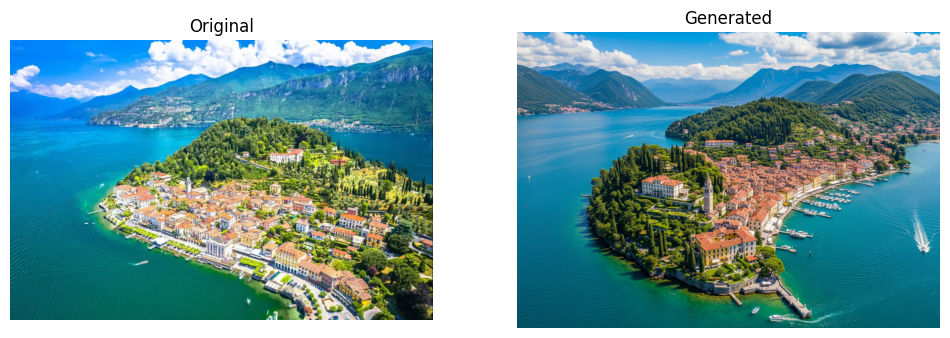

In [20]:
# Imagen 4 image generation
response = client.models.generate_images(
    model="imagen-4.0-ultra-generate-001",
    prompt=image_description,
    config=types.GenerateImagesConfig(
        number_of_images=1,
        aspect_ratio="4:3",
        image_size="2K",
        safety_filter_level="BLOCK_MEDIUM_AND_ABOVE",
        person_generation="ALLOW_ADULT",
    ),
)

starting_image_show = PIL_Image.open(
    urllib.request.urlopen(
        f"https://storage.googleapis.com/{bucket_name}/{path}"
    )
)

# Display generated images
fig, axis = plt.subplots(1, 2, figsize=(12, 6))
axis[0].imshow(starting_image_show)
axis[0].set_title("Original")
axis[1].imshow(response.generated_images[0].image._pil_image)
axis[1].set_title("Generated")
for ax in axis:
    ax.axis("off")
plt.show()
